# CLIP Embedding Sanity Check
Pick a random item, find its most similar items by cosine similarity in the CLIP image embedding space, and display them side-by-side.

If embeddings are working correctly, the nearest neighbours should be visually similar products (same category, similar style/colour).

In [1]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os
import random

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_FOLDER   = "../data/"
IMAGES_FOLDER = "../../images/"   # large folder — only opened per-item, never listed
EMB_PATH      = "fashion_clip_image_embeddings.pt"

# ── Load embeddings ───────────────────────────────────────────────────────────
print("Loading CLIP image embeddings...")
emb_raw = torch.load(EMB_PATH, map_location="cpu", weights_only=False)
sample_key = next(iter(emb_raw))
print(f"  {len(emb_raw):,} embeddings  |  key type: {type(sample_key).__name__}  |  dim: {emb_raw[sample_key].shape[0]}")

# ── Load item metadata (for title, geo, price) ────────────────────────────────
print("Loading item metadata...")
df = pd.read_csv(os.path.join(DATA_FOLDER, "items_train.csv"))
# Keep only items that have an embedding
df['itemId_str'] = df['itemId'].astype(str)
df = df[df['itemId_str'].isin({str(k) for k in emb_raw.keys()})].reset_index(drop=True)
print(f"  Items with embeddings: {len(df):,}")


Loading CLIP image embeddings...
  220,224 embeddings  |  key type: str  |  dim: 512
Loading item metadata...
  Items with embeddings: 220,224


In [2]:
# ── Build normalised embedding matrix ────────────────────────────────────────
# Stack all embeddings in the same order as df rows
print("Building embedding matrix...")
item_ids = df['itemId_str'].tolist()

def _get_emb(iid):
    v = emb_raw.get(iid)
    if v is None:
        v = emb_raw.get(int(iid))
    return v

emb_matrix = torch.stack([_get_emb(iid) for iid in item_ids]).float()  # (N, D)
emb_matrix = F.normalize(emb_matrix, dim=1)                             # unit vectors → dot product = cosine sim
print(f"  Embedding matrix: {emb_matrix.shape}  (normalised)")


Building embedding matrix...
  Embedding matrix: torch.Size([220224, 512])  (normalised)


In [3]:
def find_nearest_neighbours(query_idx, emb_matrix, top_k=8, exclude_self=True):
    """Return indices and cosine similarities of the top-k nearest neighbours."""
    query_emb = emb_matrix[query_idx].unsqueeze(0)          # (1, D)
    sims      = torch.mv(emb_matrix, query_emb.squeeze(0))  # (N,)  — fast dot product
    if exclude_self:
        sims[query_idx] = -1.0
    top_sims, top_idx = torch.topk(sims, top_k)
    return top_idx.numpy(), top_sims.numpy()


def load_image(item_id):
    path = os.path.join(IMAGES_FOLDER, f"{item_id}.jpg")
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None


def show_neighbours(query_idx, emb_matrix, df, top_k=8, title_chars=45):
    """Display query item and its top-k nearest neighbours by CLIP cosine similarity."""
    nn_idx, nn_sims = find_nearest_neighbours(query_idx, emb_matrix, top_k=top_k)

    query_row = df.iloc[query_idx]
    rows_to_show = [query_row] + [df.iloc[i] for i in nn_idx]
    sims_to_show = [1.0]       + list(nn_sims)
    labels       = ["QUERY"]   + [f"sim={s:.3f}" for s in nn_sims]

    n_cols = len(rows_to_show)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 7))

    for ax, row, sim_label, is_query in zip(
        axes, rows_to_show, labels, [True] + [False] * top_k
    ):
        iid = str(row['itemId'])
        img = load_image(iid)

        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "no image", ha="center", va="center",
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor("#eeeeee")

        # Highlight query with blue border, neighbours by same-label status
        query_label = query_row['label']
        is_same_label = (not is_query) and (row['label'] == query_label)

        border_color = "#1565C0" if is_query else ("#2e7d32" if is_same_label else "#c62828")
        lw = 4 if is_query else 3

        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(lw)

        title_line = str(row.get('title', ''))[:title_chars]
        geo        = str(row.get('geo', ''))
        price      = row.get('price', '')
        label_str  = f"label={row['label']}"

        ax.set_title(f"{sim_label}\n{title_line}\n{geo} | {price}\n{label_str}",
                     fontsize=9, pad=6)
        ax.set_xticks([])
        ax.set_yticks([])

    # Legend
    patches = [
        mpatches.Patch(color="#1565C0", label="Query"),
        mpatches.Patch(color="#2e7d32", label="Same label (true duplicate)"),
        mpatches.Patch(color="#c62828", label="Different label"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10,
               bbox_to_anchor=(0.5, -0.05))

    fig.suptitle(
        f"Query: itemId={query_row['itemId']}  label={query_row['label']}  geo={query_row.get('geo','')}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


print("Functions defined — ready to explore!")


Functions defined — ready to explore!


In [4]:
def how_many_with_same_label(label,df):
    return len(df[df['label'] == label])

Items with same label:  23
Query index: 68136  →  itemId=295367


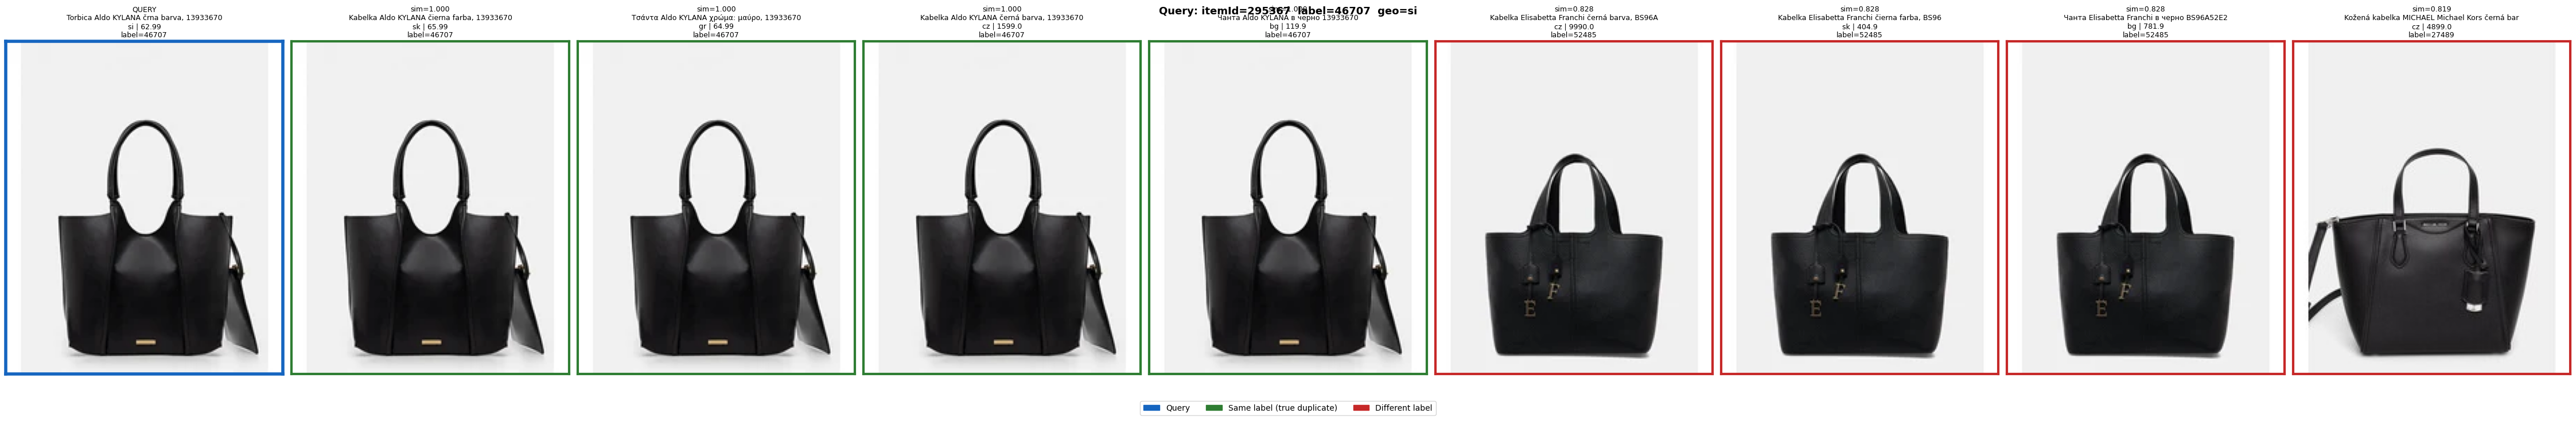

In [29]:
# ── Pick a random item and show its nearest neighbours ────────────────────────
# random.seed(42)
query_idx = random.randint(0, len(df) - 1)
item_label = df.iloc[query_idx]['label']

print("Items with same label: ",how_many_with_same_label(item_label,df))
print(f"Query index: {query_idx}  →  itemId={df.iloc[query_idx]['itemId']}")

show_neighbours(query_idx, emb_matrix, df, top_k=8)


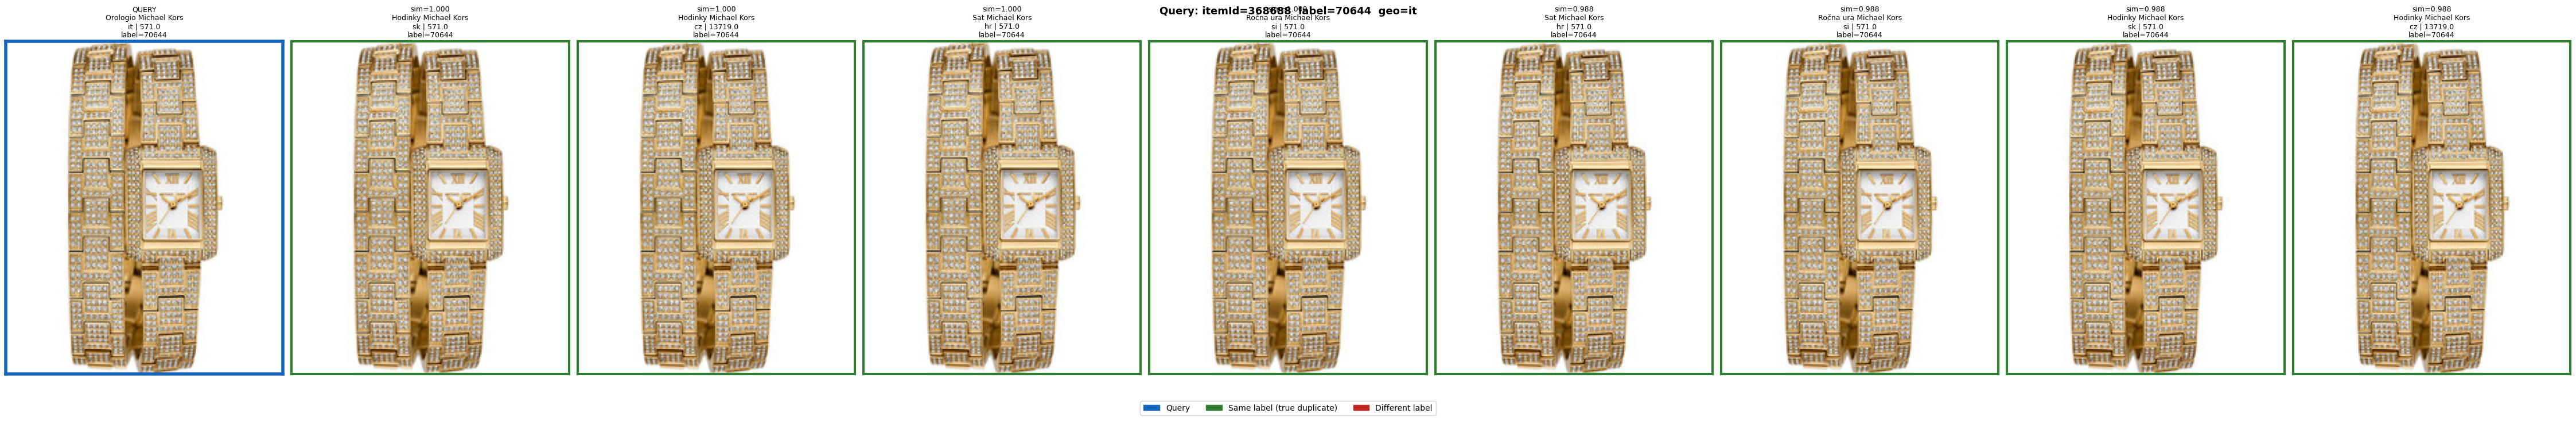

In [6]:
# ── Try a specific item by itemId ─────────────────────────────────────────────
# Change this to any itemId you want to inspect
ITEM_ID = df.iloc[1000]['itemId']

idx = df[df['itemId'] == ITEM_ID].index
if len(idx) == 0:
    print(f"itemId {ITEM_ID} not found in df")
else:
    show_neighbours(idx[0], emb_matrix, df, top_k=8)


Over 200 random queries, top-8 neighbours:
  Mean same-label neighbours : 5.80 / 8
  Queries with ≥1 same-label : 100.0%
  Queries with ≥3 same-label : 78.5%
  Queries with 0 same-label  : 0.0%


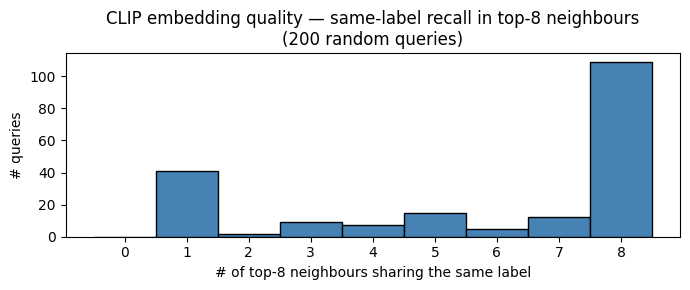

In [7]:
# ── Bulk sanity check: for N random queries, what % of top-8 neighbours share the same label? ──
N_QUERIES   = 200
TOP_K       = 8
random.seed(0)
query_indices = random.sample(range(len(df)), N_QUERIES)

same_label_hits = []

for qi in query_indices:
    nn_idx, _ = find_nearest_neighbours(qi, emb_matrix, top_k=TOP_K)
    query_label = df.iloc[qi]['label']
    hits = sum(1 for i in nn_idx if df.iloc[i]['label'] == query_label)
    same_label_hits.append(hits)

hits_arr = np.array(same_label_hits)
print(f"Over {N_QUERIES} random queries, top-{TOP_K} neighbours:")
print(f"  Mean same-label neighbours : {hits_arr.mean():.2f} / {TOP_K}")
print(f"  Queries with ≥1 same-label : {(hits_arr >= 1).mean():.1%}")
print(f"  Queries with ≥3 same-label : {(hits_arr >= 3).mean():.1%}")
print(f"  Queries with 0 same-label  : {(hits_arr == 0).mean():.1%}")

plt.figure(figsize=(7, 3))
plt.hist(hits_arr, bins=range(TOP_K + 2), align='left', edgecolor='black', color='steelblue')
plt.xlabel(f"# of top-{TOP_K} neighbours sharing the same label")
plt.ylabel("# queries")
plt.title(f"CLIP embedding quality — same-label recall in top-{TOP_K} neighbours\n({N_QUERIES} random queries)")
plt.xticks(range(TOP_K + 1))
plt.tight_layout()
plt.show()
